# Phase 4 — Anomaly and Outlier Detection

**Owner:** Data Engineer & Pattern Analyst
**Dataset:** `processed_dataset.csv` (hasil Phase 1), 99.994 baris x 80 kolom

**Tujuan Fase:** Mengidentifikasi record yang menyimpang signifikan dari populasi,
lalu menentukan apakah tiap penyimpangan itu **kesalahan input data**, **kasus
ekstrem namun sah (legitimate)**, atau **sinyal risiko** yang perlu ditindaklanjuti.

**Alur:**
1. Bersihkan kolom finansial yang tersimpan sebagai string (`exempt`, bucket DTI/usia)
2. Deteksi anomali univariat -- **IQR** & **Z-score** per kolom
3. Deteksi anomali struktural (multivariat) -- **Isolation Forest**
4. Cross-reference dengan outlier cluster dari **Phase 2** (KMeans distance-to-centroid + DBSCAN noise)
5. Gabungkan jadi tingkat kepercayaan anomali (tier) & investigasi tipologi bisnis
6. Ekspor laporan anomali (`reports/4-anomalies.csv`, `reports/4-anomaly-report.txt`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed_dataset.csv", low_memory=False)
print(f"Dataset dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head(3)


Dataset dimuat: 99,994 baris x 80 kolom


,derived_msa_md,state_code,county_code,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,preapproval,lien_status,reverse_mortgage,loan_amount,...,loan_purpose_32,loan_purpose_4,loan_purpose_5,income_bracket_High,income_bracket_Low,income_bracket_Medium,income_bracket_Very High,loan_size_Large,loan_size_Medium,loan_size_Small
0,12580,md,24005.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,465000,...,0,0,0,0,0,0,1,1,0,0
1,22220,ar,5007.0,c,conventional:first lien,single family (1-4 units):site-built,2,1,2,125000,...,0,0,0,0,0,0,1,0,0,1
2,43900,sc,45083.0,c,conventional:subordinate lien,single family (1-4 units):site-built,2,2,2,55000,...,0,1,0,0,0,0,0,0,0,1


## 1. Persiapan Fitur Numerik

Beberapa kolom finansial di `processed_dataset.csv` tersimpan sebagai **string**,
bukan `int64`/`float64` murni, karena mencampur nilai numerik dengan kategori
non-numerik bawaan skema HMDA:

- **`"exempt"`** -- institusi pelapor dikecualikan dari kewajiban melaporkan
  field tersebut untuk baris itu (bukan data hilang biasa, bukan error).
- **`debt_to_income_ratio`** -- HMDA melaporkan DTI sebagai angka persis untuk
  rentang tengah (mis. `"44"`), tetapi sebagai *bucket* bertepi di ekor
  distribusi (`"<20%"`, `"20%-<30%"`, `"50%-60%"`, `">60%"`) untuk melindungi
  privasi pemohon.
- **`applicant_age`** -- dilaporkan sebagai kelompok usia (`"25-34"`, dst.)
  dengan sentinel `8888` untuk "tidak tersedia".

Untuk deteksi anomali numerik, kolom-kolom ini dikonversi: `"exempt"` -> `NaN`,
bucket -> titik tengah rentang (mis. `"20%-<30%"` -> `25.0`), sentinel `8888` -> `NaN`.
Ini mengikuti konvensi yang sama dengan Phase 3 (`pd.to_numeric(..., errors="coerce")`
untuk `exempt`, sentinel mapping untuk usia).


In [2]:
DTI_BUCKET_MAP = {
    "<20%": 15.0, "20%-<30%": 25.0, "30%-<36%": 33.0,
    "50%-60%": 55.0, ">60%": 65.0,
}
AGE_BUCKET_MAP = {
    "<25": 20.0, "25-34": 29.5, "35-44": 39.5, "45-54": 49.5,
    "55-64": 59.5, "65-74": 69.5, ">74": 80.0,
}

def clean_exempt_numeric(s):
    s = s.astype(str).str.strip().str.lower().replace({"exempt": np.nan})
    return pd.to_numeric(s, errors="coerce")

def clean_bucketed(s, bucket_map, sentinel=None):
    s = s.astype(str).str.strip()
    mapped = s.map(bucket_map)
    numeric = pd.to_numeric(s, errors="coerce")
    out = mapped.fillna(numeric)
    if sentinel is not None:
        out = out.replace(sentinel, np.nan)
    return out

clean = pd.DataFrame(index=df.index)
clean["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")
clean["income"] = pd.to_numeric(df["income"], errors="coerce")
clean["combined_loan_to_value_ratio"] = clean_exempt_numeric(df["combined_loan_to_value_ratio"])
clean["interest_rate"] = clean_exempt_numeric(df["interest_rate"])
clean["rate_spread"] = clean_exempt_numeric(df["rate_spread"])
clean["loan_term"] = clean_exempt_numeric(df["loan_term"])
clean["total_loan_costs"] = clean_exempt_numeric(df["total_loan_costs"])
clean["origination_charges"] = clean_exempt_numeric(df["origination_charges"])
clean["debt_to_income_ratio"] = clean_bucketed(df["debt_to_income_ratio"], DTI_BUCKET_MAP)
clean["applicant_age"] = clean_bucketed(df["applicant_age"], AGE_BUCKET_MAP, sentinel=8888.0)
clean["tract_population"] = pd.to_numeric(df["tract_population"], errors="coerce")
clean["tract_minority_population_percent"] = pd.to_numeric(df["tract_minority_population_percent"], errors="coerce")
clean["tract_to_msa_income_percentage"] = pd.to_numeric(df["tract_to_msa_income_percentage"], errors="coerce")
clean["tract_owner_occupied_units"] = pd.to_numeric(df["tract_owner_occupied_units"], errors="coerce")
clean["tract_median_age_of_housing_units"] = pd.to_numeric(df["tract_median_age_of_housing_units"], errors="coerce")

UNIVARIATE_COLS = list(clean.columns)
# rate_spread/total_loan_costs/origination_charges dikecualikan dari matriks Isolation
# Forest karena missing > 50% (exempt reporter besar) -- imputasi median akan
# mendominasi sinyal jarak, bukan mencerminkan anomali sungguhan.
IF_FEATURES = [c for c in UNIVARIATE_COLS if c not in ("rate_spread", "total_loan_costs", "origination_charges")]

missing_pct = (clean.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Persentase missing per kolom setelah cleaning (exempt/bucket -> NaN):")
display(missing_pct.to_frame("missing_%"))


Persentase missing per kolom setelah cleaning (exempt/bucket -> NaN):


,missing_%
total_loan_costs,53.30
origination_charges,52.87
rate_spread,51.02
interest_rate,36.49
combined_loan_to_value_ratio,34.51
debt_to_income_ratio,33.94
income,11.18
applicant_age,10.19
loan_term,3.50
loan_amount,0.00


## 2. Metode Statistik 1 -- IQR (Interquartile Range)

Untuk tiap kolom: `lower = Q1 - 1.5*IQR`, `upper = Q3 + 1.5*IQR`. Nilai di luar
rentang ini ditandai sebagai outlier univariat. Metode ini **robust** terhadap
distribusi skewed karena berbasis kuantil, bukan mean/std -- cocok untuk kolom
finansial yang secara konsisten right-skewed (lihat Phase 1 & Phase 3).

**Guard IQR degenerate:** jika `Q1 == Q3` (IQR = 0), batas `lower == upper`
menandai *setiap* nilai yang berbeda dari itu sebagai "outlier" -- palsu total,
bukan sinyal anomali. Ini persis terjadi pada `loan_term`: 74% data persis di
360 bulan (30 tahun) sehingga `Q1 = Q3 = 360`. Ini adalah pengulangan temuan
Phase 3 (loan_term adalah **variabel produk**, bukan kontinu murni -- lihat
`3-explanation.md`). Kolom dengan IQR = 0 dikecualikan dari flagging IQR
(bounds diset tak-hingga, tidak ada baris ditandai dari kolom itu) supaya tidak
mencemari `stat_score`; boxplot-nya tetap ditampilkan sebagai ilustrasi kenapa
metode ini gagal pada variabel produk.


In [3]:
iqr_flags = pd.DataFrame(index=df.index)
iqr_bounds = {}
degenerate_iqr_cols = []
for col in UNIVARIATE_COLS:
    s = clean[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        # IQR degenerate (Q1==Q3): setiap nilai != Q1 akan "difitnah" sebagai
        # outlier walau bukan anomali finansial -- kecualikan dari flagging.
        degenerate_iqr_cols.append(col)
        lower, upper = -np.inf, np.inf
        iqr_flags[col] = False
    else:
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        iqr_flags[col] = (s < lower) | (s > upper)
    iqr_bounds[col] = (lower, upper)

if degenerate_iqr_cols:
    print(f"Kolom dengan IQR degenerate (Q1==Q3), dikecualikan dari flagging IQR: {degenerate_iqr_cols}")
    for col in degenerate_iqr_cols:
        q1 = clean[col].quantile(0.25)
        print(f"  - {col}: Q1=Q3={q1} ({(clean[col] == q1).mean()*100:.1f}% baris persis di nilai ini -- variabel produk, bukan kontinu)")

iqr_summary = pd.DataFrame({
    "lower_bound": {k: v[0] for k, v in iqr_bounds.items()},
    "upper_bound": {k: v[1] for k, v in iqr_bounds.items()},
    "outlier_count": iqr_flags.sum(),
    "outlier_%": (iqr_flags.mean() * 100).round(2),
}).sort_values("outlier_%", ascending=False)

print("\nRingkasan outlier IQR per kolom:")
display(iqr_summary)


Kolom dengan IQR degenerate (Q1==Q3), dikecualikan dari flagging IQR: ['loan_term']
  - loan_term: Q1=Q3=360.0 (71.9% baris persis di nilai ini -- variabel produk, bukan kontinu)

Ringkasan outlier IQR per kolom:


,lower_bound,upper_bound,outlier_count,outlier_%
income,-7.250000e+01,2.835000e+02,6310,6.31
tract_to_msa_income_percentage,1.100000e+01,2.030000e+02,5467,5.47
loan_amount,-2.600000e+05,7.400000e+05,4758,4.76
rate_spread,-1.587500e+00,2.352500e+00,3620,3.62
origination_charges,-4.304598e+03,9.827663e+03,2700,2.70
tract_population,-2.720000e+02,9.560000e+03,2524,2.52
total_loan_costs,-4.957475e+03,1.752081e+04,2223,2.22
tract_owner_occupied_units,-3.040000e+02,2.672000e+03,1527,1.53
interest_rate,6.167500e-01,8.678750e+00,1507,1.51
combined_loan_to_value_ratio,1.664000e+01,1.340160e+02,1266,1.27


## 3. Metode Statistik 2 -- Z-score

`z = (x - mean) / std`; `|z| > 3` ditandai sebagai outlier. Berbeda dari IQR,
Z-score memakai mean & std sehingga **rentan ke efek masking**: outlier ekstrem
sendiri menggelembungkan std, sehingga nilai yang "cukup ekstrem" jadi tidak
lolos ambang 3-sigma. Ini terlihat jelas pada `combined_loan_to_value_ratio`
(maksimum riil 27.778%!): IQR menangkap jauh lebih banyak baris LTV tidak wajar
dibanding Z-score, karena satu-dua nilai ekstrem menarik std ke atas dan
"menyembunyikan" outlier yang lebih moderat. Membandingkan kedua metode
berdampingan adalah cara mendeteksi masking effect ini.

Berbeda dari IQR, Z-score **tidak** degenerate pada `loan_term` (std tetap
positif walau median terpusat), sehingga tetap dipakai apa adanya untuk kolom
ini -- hanya IQR yang butuh guard karena definisinya bergantung langsung pada
Q1/Q3 yang bisa berimpit.


In [4]:
z_flags = pd.DataFrame(index=df.index)
z_scores = pd.DataFrame(index=df.index)
for col in UNIVARIATE_COLS:
    s = clean[col]
    mu, sigma = s.mean(), s.std()
    z = (s - mu) / sigma
    z_scores[col] = z
    z_flags[col] = z.abs() > 3

z_summary = pd.DataFrame({
    "mean": clean[UNIVARIATE_COLS].mean(),
    "std": clean[UNIVARIATE_COLS].std(),
    "outlier_count": z_flags.sum(),
    "outlier_%": (z_flags.mean() * 100).round(2),
}).sort_values("outlier_%", ascending=False)

print("Ringkasan outlier Z-score per kolom:")
display(z_summary)

compare_methods = pd.DataFrame({
    "IQR_%": iqr_summary["outlier_%"],
    "Zscore_%": z_summary["outlier_%"],
}).sort_values("IQR_%", ascending=False)
compare_methods["gap (masking effect)"] = (compare_methods["IQR_%"] - compare_methods["Zscore_%"]).round(2)
print("\nPerbandingan IQR vs Z-score (gap besar = indikasi masking oleh outlier ekstrem):")
display(compare_methods)

# Gabungan: berapa kolom yang menandai tiap baris sebagai outlier (union IQR OR Z-score)
stat_flag = iqr_flags | z_flags
stat_score = stat_flag.sum(axis=1)
print("\nDistribusi jumlah kolom yang menandai tiap baris sebagai outlier (stat_score):")
display(stat_score.value_counts().sort_index().to_frame("jumlah_baris"))


Ringkasan outlier Z-score per kolom:


,mean,std,outlier_count,outlier_%
loan_term,323.977905,79.667774,2141,2.14
tract_population,4775.803718,2220.392070,1254,1.25
tract_to_msa_income_percentage,108.782447,43.782860,1100,1.10
rate_spread,0.405543,1.282535,1021,1.02
interest_rate,4.772889,1.550497,992,0.99
tract_owner_occupied_units,1210.162210,592.901113,807,0.81
origination_charges,3296.352435,3930.595676,757,0.76
total_loan_costs,6998.790699,6831.423532,417,0.42
loan_amount,306264.675881,751926.642864,336,0.34
combined_loan_to_value_ratio,73.976642,117.736784,17,0.02



Perbandingan IQR vs Z-score (gap besar = indikasi masking oleh outlier ekstrem):


,IQR_%,Zscore_%,gap (masking effect)
income,6.31,0.01,6.30
tract_to_msa_income_percentage,5.47,1.10,4.37
loan_amount,4.76,0.34,4.42
rate_spread,3.62,1.02,2.60
origination_charges,2.70,0.76,1.94
tract_population,2.52,1.25,1.27
total_loan_costs,2.22,0.42,1.80
tract_owner_occupied_units,1.53,0.81,0.72
interest_rate,1.51,0.99,0.52
combined_loan_to_value_ratio,1.27,0.02,1.25



Distribusi jumlah kolom yang menandai tiap baris sebagai outlier (stat_score):


,jumlah_baris
0,75991
1,16141
2,6154
3,1327
4,307
5,60
6,13
7,1


### Visualisasi Boxplot -- Kolom Finansial Utama

Boxplot lima kolom finansial paling relevan secara bisnis, dengan batas IQR
digambar sebagai garis putus-putus merah. Panel bawah menggunakan sumbu
log/clip agar sebaran tetap terbaca meskipun ada ekor ekstrem.


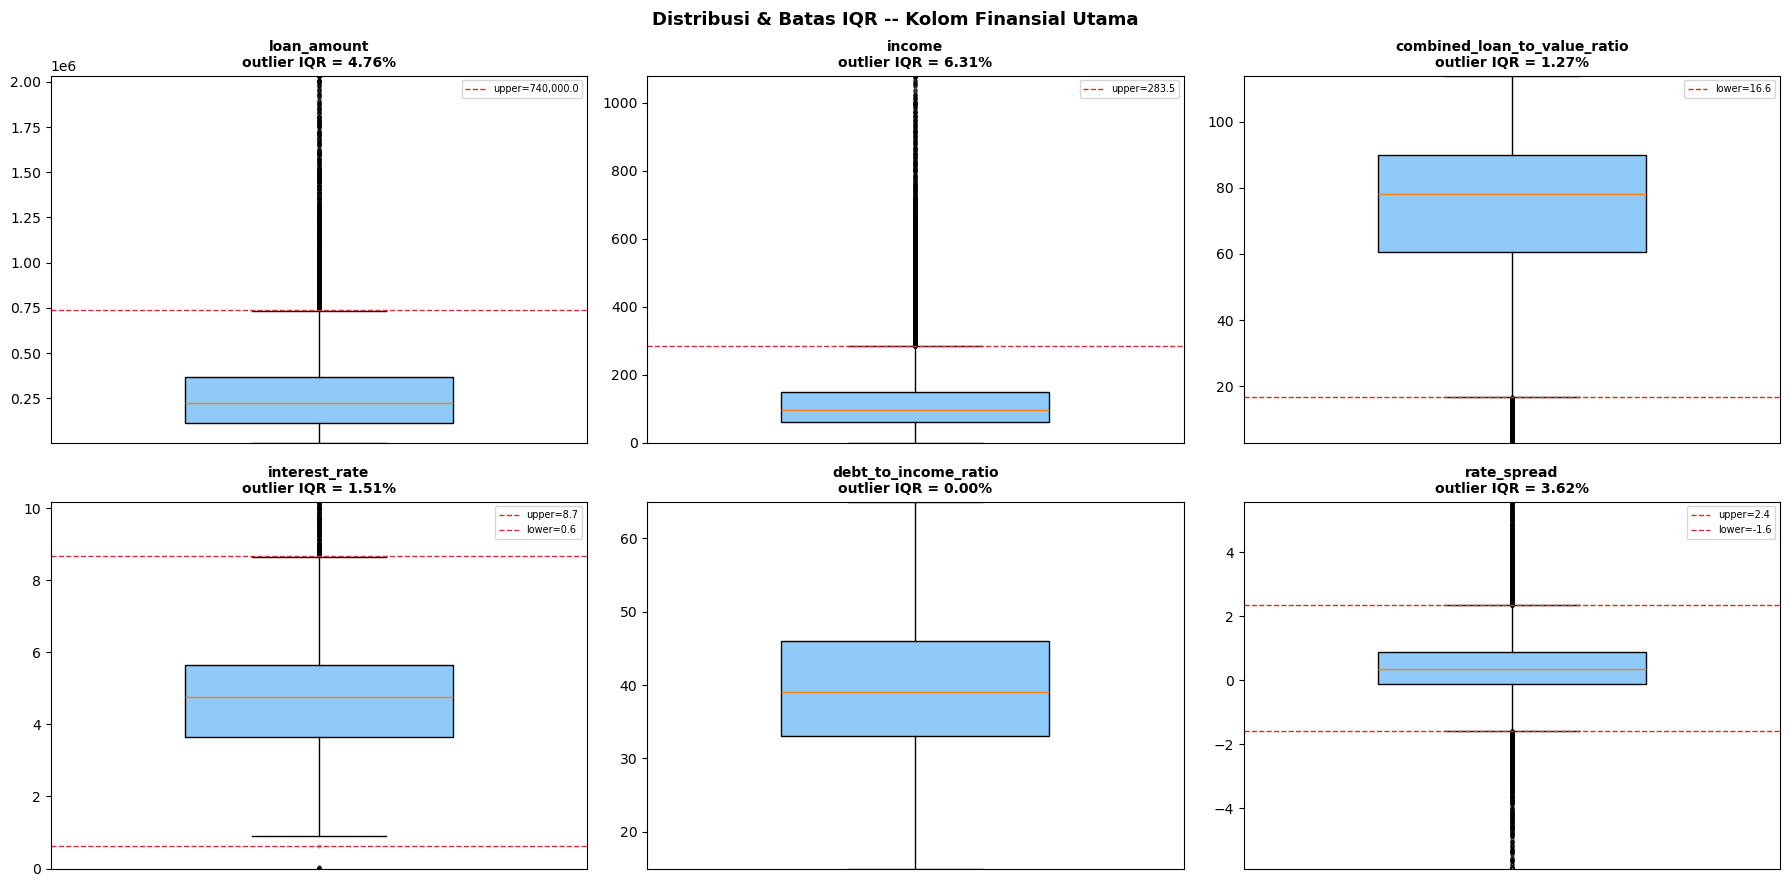

Disimpan ke: ../reports/4-outlier_boxplots.png


In [5]:
KEY_COLS = ["loan_amount", "income", "combined_loan_to_value_ratio",
            "interest_rate", "debt_to_income_ratio", "rate_spread"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, KEY_COLS):
    s = clean[col].dropna()
    lower, upper = iqr_bounds[col]
    outlier_pct = iqr_flags[col].mean() * 100
    # sumbu-y di-clip ke persentil 0.1-99.5 supaya box & whisker tetap terbaca meski
    # ada ekor sangat ekstrem (mis. income sampai $1jt+, LTV sampai 27.778%);
    # outlier_pct di judul tetap dihitung dari IQR asli (tidak diclip)
    clip_lo, clip_hi = s.quantile(0.001), s.quantile(0.995)
    s_display = s.clip(clip_lo, clip_hi)
    bp = ax.boxplot(s_display, vert=True, patch_artist=True, widths=0.5,
                     flierprops=dict(marker="o", markersize=2, alpha=0.3, color="#D32F2F"))
    bp["boxes"][0].set_facecolor("#90CAF9")
    if np.isfinite(upper) and upper <= clip_hi:
        ax.axhline(upper, color="#D32F2F", linestyle="--", linewidth=1, label=f"upper={upper:,.1f}")
    if np.isfinite(lower) and lower > clip_lo:
        ax.axhline(lower, color="#D32F2F", linestyle="--", linewidth=1, label=f"lower={lower:,.1f}")
    title_suffix = " (IQR degenerate\ndikecualikan dari stat_score)" if col in degenerate_iqr_cols else ""
    ax.set_title(f"{col}\noutlier IQR = {outlier_pct:.2f}%{title_suffix}", fontsize=10, fontweight="bold")
    ax.set_xticks([])
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=7, loc="upper right")
    # set_ylim eksplisit DIPANGGIL TERAKHIR (setelah semua artist) supaya autoscale
    # matplotlib tidak melebar ulang mengikuti garis axhline di luar rentang clip
    ax.set_ylim(clip_lo, clip_hi)

plt.suptitle("Distribusi & Batas IQR -- Kolom Finansial Utama", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/4-outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke: ../reports/4-outlier_boxplots.png")


## 4. Isolation Forest -- Deteksi Anomali Struktural

IQR & Z-score bekerja per-kolom (univariat) -- keduanya tidak bisa menangkap
**kombinasi** nilai yang masing-masing terlihat wajar sendiri-sendiri tetapi
janggal bersama (mis. income sangat rendah + LTV sangat tinggi + loan besar,
walau tak satu pun kolom individual ekstrem). Isolation Forest mengisolasi
titik lewat partisi acak berulang: titik anomali butuh lebih sedikit split
untuk terisolasi (path length lebih pendek) karena posisinya "sendirian" di
ruang fitur multivariat.

Fitur: 12 kolom numerik (`IF_FEATURES`) di-scale dengan `StandardScaler`, NaN
diisi median per kolom. `contamination=0.05` mengikuti rekomendasi Phase 1
(rentang 5-10%). `loan_term` tetap ikut sebagai fitur multivariat di sini
(bukan hanya diflagging univariat) karena Isolation Forest tidak bergantung
pada IQR/Q1/Q3 -- ia tetap bisa memakai posisi `loan_term` yang jauh dari 360
sebagai salah satu dari banyak sinyal kombinasi, tanpa risiko false-positive
massal seperti pada IQR murni.


Fitur yang dipakai (12): ['loan_amount', 'income', 'combined_loan_to_value_ratio', 'interest_rate', 'loan_term', 'debt_to_income_ratio', 'applicant_age', 'tract_population', 'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_median_age_of_housing_units']

Isolation Forest menandai 7,642 baris (7.64%) sebagai anomali struktural.


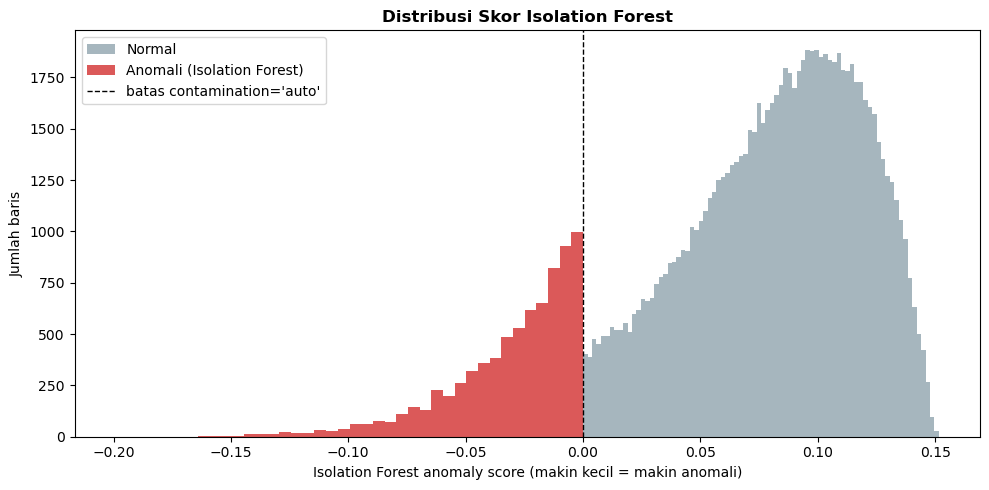

Disimpan ke: ../reports/4-isolation_forest_scores.png


In [6]:
X_if = clean[IF_FEATURES].apply(lambda x: x.fillna(x.median()))
scaler = StandardScaler()
X_if_scaled = scaler.fit_transform(X_if)

iso = IsolationForest(n_estimators=200, contamination="auto", random_state=42, n_jobs=-1)
if_pred = iso.fit_predict(X_if_scaled)
if_score = iso.decision_function(X_if_scaled)  # makin kecil (negatif) = makin anomali
if_flag = if_pred == -1

print(f"Fitur yang dipakai ({len(IF_FEATURES)}): {IF_FEATURES}")
print(f"\nIsolation Forest menandai {if_flag.sum():,} baris ({if_flag.mean()*100:.2f}%) sebagai anomali struktural.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(if_score[~if_flag], bins=80, color="#90A4AE", alpha=0.8, label="Normal")
ax.hist(if_score[if_flag], bins=40, color="#D32F2F", alpha=0.8, label="Anomali (Isolation Forest)")
threshold = if_score[if_flag].max()
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"batas contamination='auto'")
ax.set_xlabel("Isolation Forest anomaly score (makin kecil = makin anomali)")
ax.set_ylabel("Jumlah baris")
ax.set_title("Distribusi Skor Isolation Forest", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/4-isolation_forest_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke: ../reports/4-isolation_forest_scores.png")


## 5. Cross-Reference dengan Outlier Cluster Phase 2

Phase 2 tidak menyimpan label cluster/noise ke file terpisah, sehingga
langkah clustering-nya **diulang persis (reproduced)** di sini untuk
mengambil status *noise point* dari algoritma DBSCAN.

DBSCAN bersifat *density-based* dan mendeteksi anomali (noise) secara *native*.
Epsilon ditentukan secara dinamis melalui K-Distance Graph (metode *knee/elbow*),
sehingga tidak lagi menggunakan angka yang ditetapkan secara kaku (*hardcode*).


In [7]:
# --- 5a. DBSCAN Outlier Phase 2 dengan Epsilon Dinamis ---
from sklearn.neighbors import NearestNeighbors
import numpy as np

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
features_for_clustering = [c for c in numeric_cols if df[c].nunique() > 5]
X2 = df[features_for_clustering].apply(lambda x: x.fillna(x.median()), axis=0)
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

print(f"Fitur clustering Phase 2 (auto-selected, nunique>5): {features_for_clustering}")

# Di Phase 2, DBSCAN pakai subsample 5.000 karena batasan memori (kompleksitas O(N^2)).
np.random.seed(42)
idx_dbscan = np.random.choice(X2_scaled.shape[0], size=5000, replace=False)
X_dbscan_sample = X2_scaled[idx_dbscan]

# 2 x dimensi fitur
min_samples = 2 * len(features_for_clustering)

# Hitung jarak k-tetangga terdekat untuk mencari Knee Point (eps)
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_dbscan_sample)
distances, _ = nn.kneighbors(X_dbscan_sample)
k_distances = np.sort(distances[:, -1])

# Menemukan Titik Siku (Knee Point) menggunakan algoritma Kneedle yang disederhanakan
n_points = len(k_distances)
all_coord = np.vstack((range(n_points), k_distances)).T
first_point = all_coord[0]
line_vec = all_coord[-1] - all_coord[0]
line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
vec_from_first = all_coord - first_point
scalar_proj = np.sum(vec_from_first * np.tile(line_vec_norm, (n_points, 1)), axis=1)
vec_from_first_parallel = np.outer(scalar_proj, line_vec_norm)
vec_to_line = vec_from_first - vec_from_first_parallel
dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
knee_idx = np.argmax(dist_to_line)
optimal_eps = k_distances[knee_idx]

print(f"Optimal eps dari K-Distance Graph (knee point): {optimal_eps:.4f}")
print(f"Menggunakan min_samples: {min_samples}")

dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_dbscan_sample)
noise_count = int((dbscan_labels == -1).sum())
print(f"DBSCAN noise dalam sampel 5.000: {noise_count} ({noise_count/5000*100:.2f}%)")

dbscan_noise_full = pd.Series(np.nan, index=df.index)
dbscan_noise_full.iloc[idx_dbscan] = (dbscan_labels == -1).astype(float)


Fitur clustering Phase 2 (auto-selected, nunique>5): ['derived_msa_md', 'county_code', 'loan_amount', 'income', 'applicant_ethnicity_1', 'co_applicant_ethnicity_1', 'applicant_race_1', 'co_applicant_race_1', 'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage', 'tract_owner_occupied_units', 'tract_median_age_of_housing_units']
Optimal eps dari K-Distance Graph (knee point): 3.2854
Menggunakan min_samples: 28
DBSCAN noise dalam sampel 5.000: 158 (3.16%)


In [8]:
# --- 5b. Gabungkan semua sinyal jadi satu tabel anomali komposit ---
anomaly_df = pd.DataFrame({
    "stat_score": stat_score,
    "if_score": if_score,
    "if_flag": if_flag,
    "dbscan_noise": dbscan_noise_full,
}, index=df.index)

def assign_tier(row):
    cross_ref_hit = (row["dbscan_noise"] == 1.0)
    stat_hit = row["stat_score"] >= 2
    if row["if_flag"] and stat_hit and cross_ref_hit:
        return "High Confidence"
    if row["if_flag"] and (stat_hit or cross_ref_hit):
        return "Confirmed (2 metode)"
    if row["if_flag"] or stat_hit:
        return "Suspected (1 metode)"
    return "Normal"

anomaly_df["tier"] = anomaly_df.apply(assign_tier, axis=1)

print("Distribusi tingkat kepercayaan anomali (tier):")
display(anomaly_df["tier"].value_counts().to_frame("jumlah_baris"))

sampled = anomaly_df["dbscan_noise"].notna()
print(f"\nCross-tab: Isolation Forest flag vs DBSCAN noise (subset tersampel, n={sampled.sum()}):")
display(pd.crosstab(anomaly_df.loc[sampled, "if_flag"], anomaly_df.loc[sampled, "dbscan_noise"],
                     rownames=["IF anomaly"], colnames=["DBSCAN noise"]))

overlap_if_dbscan = ((anomaly_df["if_flag"]) & (anomaly_df["dbscan_noise"] == 1.0)).sum()
print(f"\nDari {noise_count} titik DBSCAN noise (Phase 2), {overlap_if_dbscan} ({overlap_if_dbscan/noise_count*100:.1f}%) "
      f"juga ditandai anomali oleh Isolation Forest -- validasi silang independen antar metode.")


Distribusi tingkat kepercayaan anomali (tier):


,jumlah_baris
tier,
Normal,87777
Suspected (1 metode),8916
Confirmed (2 metode),3282
High Confidence,19



Cross-tab: Isolation Forest flag vs DBSCAN noise (subset tersampel, n=5000):


DBSCAN noise,0.0,1.0
IF anomaly,,
False,4501,125
True,341,33



Dari 158 titik DBSCAN noise (Phase 2), 33 (20.9%) juga ditandai anomali oleh Isolation Forest -- validasi silang independen antar metode.


### Visualisasi Cross-Reference

Scatter `income` vs `loan_amount` (dua sumbu paling relevan bisnis), diwarnai
berdasarkan tier anomali. Titik "Normal" digambarkan lebih samar dengan skala grafik *linear*
serta batas yang di-clip pada rentang data persentil wajar agar tetap terlihat dengan baik.


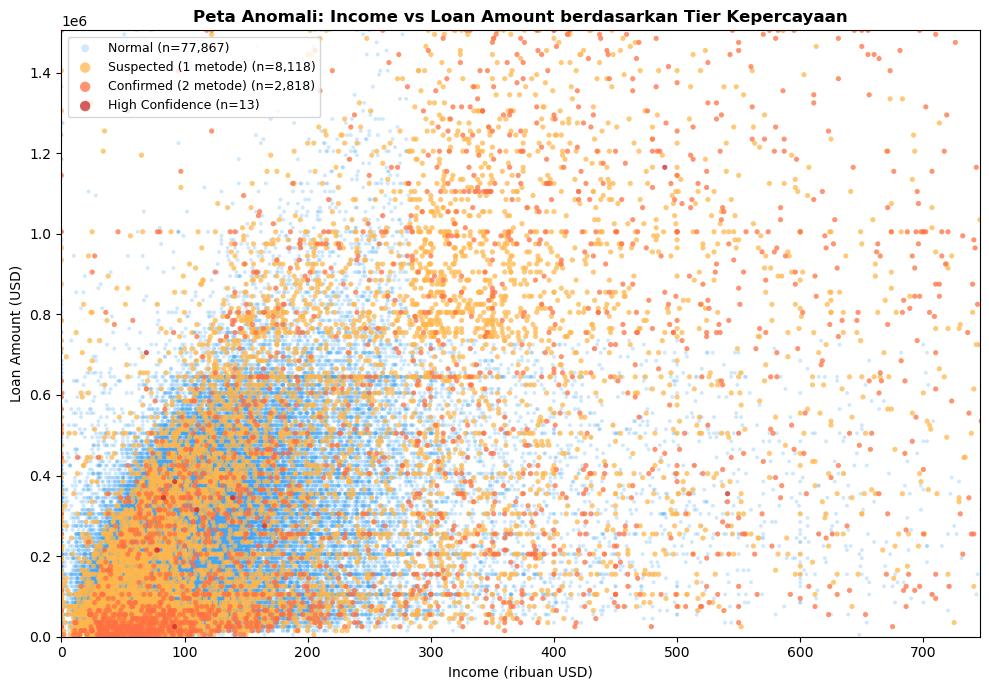

Disimpan ke: ../reports/4-anomaly_crossref.png


In [9]:
tier_colors = {
    "Normal": "#42A5F5",
    "Suspected (1 metode)": "#FFB74D",
    "Confirmed (2 metode)": "#FF7043",
    "High Confidence": "#C62828",
}
tier_order = ["Normal", "Suspected (1 metode)", "Confirmed (2 metode)", "High Confidence"]

plot_df = pd.DataFrame({
    "income": clean["income"],
    "loan_amount": clean["loan_amount"],
    "tier": anomaly_df["tier"],
}).dropna(subset=["income", "loan_amount"])

fig, ax = plt.subplots(figsize=(10, 7))
for t in tier_order:
    sub = plot_df[plot_df["tier"] == t]
    ax.scatter(sub["income"], sub["loan_amount"], s=8 if t == "Normal" else 14,
               alpha=0.25 if t == "Normal" else 0.75,
               c=tier_colors[t], label=f"{t} (n={len(sub):,})", edgecolors="none")

ax.set_xlabel("Income (ribuan USD)")
ax.set_xlim(0, clean["income"].quantile(0.99))
ax.set_ylabel("Loan Amount (USD)")
ax.set_ylim(0, clean["loan_amount"].quantile(0.99))
ax.set_title("Peta Anomali: Income vs Loan Amount berdasarkan Tier Kepercayaan", fontsize=12, fontweight="bold")
ax.legend(markerscale=2, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("../reports/4-anomaly_crossref.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke: ../reports/4-anomaly_crossref.png")


## 6. Investigasi Tipologi Anomali

Setiap baris yang ditandai anomali (tier != "Normal") diperiksa dengan aturan
bisnis untuk memutuskan kategori penjelasan:

- **Data Error** -- pelanggaran batas fisik/logis yang mustahil secara bisnis:
  `tract_median_age_of_housing_units < 0` (usia bangunan negatif), LTV > 150%
  (utang 1,5x nilai jaminan tanpa penjelasan piggyback wajar), `interest_rate <= 0`,
  `loan_term > 480` bulan (>40 tahun, di luar produk KPR AS manapun), atau
  `income == 0` sementara pengajuan disetujui dengan `loan_amount > 0`.
- **Potential Risk Signal** -- kombinasi kapasitas bayar lemah + leverage tinggi:
  income <= Q1 populasi **dan** loan_amount >= Q3 populasi, **dan** (LTV >= 95%
  **atau** DTI >= 50%); atau `rate_spread >= 5` (indikator pinjaman berbunga
  tinggi / *higher-priced mortgage* menurut definisi HMDA/HOEPA).
- **Rare Legitimate** -- income >= Q3 populasi, LTV <= 60% (uang muka besar),
  loan_amount >= Q3 -- profil ini cocok dengan Cluster 2 "High-Net-Worth
  Conservative Borrowers" pada laporan Phase 2.
- **Unclassified / Manual Review** -- anomali nyata secara statistik tetapi tidak
  cocok pola bisnis baku manapun di atas; butuh audit manual oleh underwriter.
  Wajar jika kategori ini besar -- **tidak semua penyimpangan statistik punya
  penjelasan otomatis**, itulah alasan deliverable fase ini adalah watchlist
  untuk investigasi manusia, bukan keputusan otomatis.


In [10]:
flagged = anomaly_df[anomaly_df["tier"] != "Normal"].join(clean)

q1_income, q3_income = clean["income"].quantile([0.25, 0.75])
q3_loan = clean["loan_amount"].quantile(0.75)

def classify_typology(row):
    if row["tract_median_age_of_housing_units"] < 0:
        return "Data Error"
    if pd.notna(row["combined_loan_to_value_ratio"]) and row["combined_loan_to_value_ratio"] > 150:
        return "Data Error"
    if pd.notna(row["interest_rate"]) and row["interest_rate"] <= 0:
        return "Data Error"
    if pd.notna(row["loan_term"]) and row["loan_term"] > 480:
        return "Data Error"
    if row["income"] == 0 and row["loan_amount"] > 0:
        return "Data Error"

    risk = False
    if pd.notna(row["income"]) and pd.notna(row["loan_amount"]):
        if row["income"] <= q1_income and row["loan_amount"] >= q3_loan:
            high_ltv = pd.notna(row["combined_loan_to_value_ratio"]) and row["combined_loan_to_value_ratio"] >= 95
            high_dti = pd.notna(row["debt_to_income_ratio"]) and row["debt_to_income_ratio"] >= 50
            if high_ltv or high_dti:
                risk = True
    if pd.notna(row["rate_spread"]) and row["rate_spread"] >= 5:
        risk = True
    if risk:
        return "Potential Risk Signal"

    if pd.notna(row["income"]) and pd.notna(row["combined_loan_to_value_ratio"]) and pd.notna(row["loan_amount"]):
        if row["income"] >= q3_income and row["combined_loan_to_value_ratio"] <= 60 and row["loan_amount"] >= q3_loan:
            return "Rare Legitimate"

    return "Unclassified / Manual Review"

flagged = flagged.copy()
flagged["typology"] = flagged.apply(classify_typology, axis=1)

print(f"Total baris ditandai anomali (tier != Normal): {len(flagged):,} ({len(flagged)/len(df)*100:.2f}% dari populasi)\n")
print("Distribusi tipologi (seluruh anomali):")
typ_all = flagged["typology"].value_counts()
display(pd.DataFrame({"jumlah": typ_all, "persen": (typ_all / len(flagged) * 100).round(1)}))

priority = flagged[flagged["tier"].isin(["High Confidence", "Confirmed (2 metode)"])]
print(f"\nFokus prioritas -- tier High Confidence + Confirmed (2 metode): {len(priority):,} baris")
typ_priority = priority["typology"].value_counts()
display(pd.DataFrame({"jumlah": typ_priority, "persen": (typ_priority / len(priority) * 100).round(1)}))

print("\nCross-tab tier vs tipologi (seluruh anomali):")
display(pd.crosstab(flagged["tier"], flagged["typology"]))


Total baris ditandai anomali (tier != Normal): 12,217 (12.22% dari populasi)

Distribusi tipologi (seluruh anomali):


,jumlah,persen
typology,,
Unclassified / Manual Review,10699,87.6
Rare Legitimate,709,5.8
Data Error,455,3.7
Potential Risk Signal,354,2.9



Fokus prioritas -- tier High Confidence + Confirmed (2 metode): 3,301 baris


,jumlah,persen
typology,,
Unclassified / Manual Review,2674,81.0
Rare Legitimate,372,11.3
Data Error,179,5.4
Potential Risk Signal,76,2.3



Cross-tab tier vs tipologi (seluruh anomali):


typology,Data Error,Potential Risk Signal,Rare Legitimate,Unclassified / Manual Review
tier,,,,
Confirmed (2 metode),179,76,371,2656
High Confidence,0,0,1,18
Suspected (1 metode),276,278,337,8025


### Contoh Konkret per Tipologi

Sample record untuk tiap kategori (prioritas: High Confidence -> Confirmed),
kolom bisnis yang relevan saja.


In [11]:
display_cols = ["loan_amount", "income", "combined_loan_to_value_ratio", "interest_rate",
                "debt_to_income_ratio", "rate_spread", "loan_term",
                "tract_median_age_of_housing_units", "dbscan_noise", "tier"]

examples = {}
for typ in ["Data Error", "Potential Risk Signal", "Rare Legitimate", "Unclassified / Manual Review"]:
    sub = flagged[flagged["typology"] == typ].sort_values("tier")
    examples[typ] = sub[display_cols].head(5)
    print(f"\n--- {typ} (n={len(sub):,}) ---")
    display(examples[typ])



--- Data Error (n=455) ---


,loan_amount,income,combined_loan_to_value_ratio,interest_rate,debt_to_income_ratio,rate_spread,loan_term,tract_median_age_of_housing_units,dbscan_noise,tier
47717,5000,NaN,NaN,0.0,NaN,NaN,36.0,61,NaN,Confirmed (2 metode)
43107,15000,47.0,73.143,0.0,45.0,NaN,60.0,42,NaN,Confirmed (2 metode)
43946,15000,360.0,999.999,NaN,15.0,NaN,180.0,19,NaN,Confirmed (2 metode)
45102,25000,0.0,8.670,NaN,33.0,NaN,60.0,38,NaN,Confirmed (2 metode)
46315,5000,40.0,101.833,0.0,43.0,-5.879,120.0,44,NaN,Confirmed (2 metode)



--- Potential Risk Signal (n=354) ---


,loan_amount,income,combined_loan_to_value_ratio,interest_rate,debt_to_income_ratio,rate_spread,loan_term,tract_median_age_of_housing_units,dbscan_noise,tier
25893,85000,449.0,90.000,9.75,25.0,5.480,120.0,22,NaN,Confirmed (2 metode)
67540,65000,71.0,NaN,10.65,37.0,6.482,120.0,0,0.0,Confirmed (2 metode)
81941,15000,34.0,NaN,10.50,42.0,8.456,144.0,0,NaN,Confirmed (2 metode)
20793,45000,42.0,NaN,11.40,42.0,6.519,236.0,33,NaN,Confirmed (2 metode)
19996,55000,160.0,95.011,10.99,55.0,6.320,60.0,14,NaN,Confirmed (2 metode)



--- Rare Legitimate (n=709) ---


,loan_amount,income,combined_loan_to_value_ratio,interest_rate,debt_to_income_ratio,rate_spread,loan_term,tract_median_age_of_housing_units,dbscan_noise,tier
51529,1505000,329.0,45.455,NaN,65.0,NaN,360.0,33,NaN,Confirmed (2 metode)
60735,3485000,994.0,60.000,4.750,33.0,1.158,480.0,46,NaN,Confirmed (2 metode)
59910,455000,154.0,53.224,3.125,25.0,0.245,360.0,11,NaN,Confirmed (2 metode)
59445,1235000,480.0,30.788,2.750,44.0,-0.083,360.0,54,NaN,Confirmed (2 metode)
59407,905000,531.0,55.000,3.150,25.0,NaN,360.0,18,NaN,Confirmed (2 metode)



--- Unclassified / Manual Review (n=10,699) ---


,loan_amount,income,combined_loan_to_value_ratio,interest_rate,debt_to_income_ratio,rate_spread,loan_term,tract_median_age_of_housing_units,dbscan_noise,tier
7,395000,NaN,50.000,NaN,NaN,NaN,360.0,8,NaN,Confirmed (2 metode)
44669,755000,467.0,89.990,NaN,25.0,NaN,180.0,54,NaN,Confirmed (2 metode)
21791,1275000,386.0,80.000,5.375,39.0,-1.358,360.0,25,NaN,Confirmed (2 metode)
44660,145000,123.0,69.920,NaN,33.0,NaN,360.0,12,NaN,Confirmed (2 metode)
21816,1005000,757.0,60.136,3.740,33.0,-1.150,264.0,10,NaN,Confirmed (2 metode)


## 7. Ekspor Deliverable

Dua file dihasilkan:
- **`reports/4-anomalies.csv`** -- seluruh baris yang ditandai anomali beserta
  skor tiap metode, tier, dan tipologi (untuk ditindaklanjuti tim underwriting).
- **`reports/4-anomaly-report.txt`** -- ringkasan naratif untuk pembaca non-teknis.


In [12]:
export_cols = ["loan_amount", "income", "combined_loan_to_value_ratio", "interest_rate",
               "debt_to_income_ratio", "rate_spread", "loan_term", "total_loan_costs",
               "origination_charges", "tract_population", "tract_minority_population_percent",
               "tract_to_msa_income_percentage", "tract_median_age_of_housing_units",
               "applicant_age"]

anomalies_export = flagged[export_cols].copy()
anomalies_export.insert(0, "row_index", anomalies_export.index)
anomalies_export["stat_score"] = flagged["stat_score"]
anomalies_export["if_score"] = flagged["if_score"].round(4)
anomalies_export["if_flag"] = flagged["if_flag"]
anomalies_export["dbscan_noise"] = flagged["dbscan_noise"]
anomalies_export["dbscan_noise"] = flagged["dbscan_noise"]
anomalies_export["tier"] = flagged["tier"]
anomalies_export["typology"] = flagged["typology"]
anomalies_export = anomalies_export.sort_values(["tier", "if_score"],
                                                  key=lambda s: s.map({"High Confidence": 0, "Confirmed (2 metode)": 1,
                                                                        "Suspected (1 metode)": 2}) if s.name == "tier" else s)

def safe_write_csv(dframe, path):
    try:
        dframe.to_csv(path, index=False)
        return path
    except PermissionError:
        alt = path.replace(".csv", "_new.csv")
        dframe.to_csv(alt, index=False)
        return alt

csv_path = safe_write_csv(anomalies_export, "../reports/4-anomalies.csv")
print(f"Disimpan {len(anomalies_export):,} baris anomali ke: {csv_path}")
anomalies_export.head(10)


Disimpan 12,217 baris anomali ke: ../reports/4-anomalies.csv


,row_index,loan_amount,income,combined_loan_to_value_ratio,interest_rate,debt_to_income_ratio,rate_spread,loan_term,total_loan_costs,origination_charges,...,tract_minority_population_percent,tract_to_msa_income_percentage,tract_median_age_of_housing_units,applicant_age,stat_score,if_score,if_flag,dbscan_noise,tier,typology
94275,94275,24275000,NaN,40.666,5.670,NaN,NaN,60.0,NaN,NaN,...,0.00,0.0,0,NaN,3,-0.1394,True,1.0,High Confidence,Unclassified / Manual Review
44059,44059,3085000,3059.0,73.530,NaN,15.0,NaN,360.0,NaN,NaN,...,18.44,149.0,73,49.5,2,-0.1164,True,1.0,High Confidence,Unclassified / Manual Review
27286,27286,2005000,620.0,52.000,5.375,45.0,-1.248,360.0,NaN,NaN,...,0.00,0.0,0,49.5,3,-0.1103,True,1.0,High Confidence,Rare Legitimate
97612,97612,9505000,NaN,59.000,8.030,NaN,NaN,160.0,NaN,NaN,...,49.58,0.0,66,NaN,2,-0.0934,True,1.0,High Confidence,Unclassified / Manual Review
33528,33528,215000,78.0,36.414,3.250,33.0,0.184,360.0,3807.96,2306.00,...,21.56,168.0,6,69.5,2,-0.0695,True,1.0,High Confidence,Unclassified / Manual Review
32856,32856,25000,92.0,80.920,NaN,55.0,NaN,360.0,NaN,NaN,...,69.70,141.0,6,59.5,2,-0.0621,True,1.0,High Confidence,Unclassified / Manual Review
55529,55529,385000,92.0,96.500,4.500,47.0,0.394,360.0,9650.78,0.00,...,51.39,190.0,6,29.5,2,-0.0621,True,1.0,High Confidence,Unclassified / Manual Review
73028,73028,345000,139.0,96.500,5.124,44.0,1.265,360.0,14008.28,6272.41,...,69.70,141.0,6,39.5,2,-0.0560,True,1.0,High Confidence,Unclassified / Manual Review
31192,31192,12675000,NaN,76.030,3.750,NaN,NaN,42.0,NaN,NaN,...,36.24,81.0,62,NaN,2,-0.0408,True,1.0,High Confidence,Unclassified / Manual Review
24150,24150,315000,110.0,NaN,NaN,NaN,NaN,360.0,NaN,NaN,...,58.19,211.0,8,49.5,3,-0.0403,True,1.0,High Confidence,Unclassified / Manual Review


In [13]:
def safe_write_txt(text, path):
    try:
        with open(path, "w", encoding="utf-8") as f:
            f.write(text)
        return path
    except PermissionError:
        alt = path.replace(".txt", "_new.txt")
        with open(alt, "w", encoding="utf-8") as f:
            f.write(text)
        return alt

n_total = len(df)
n_flagged = len(flagged)
n_priority = len(priority)
iqr_top = iqr_summary.sort_values("outlier_%", ascending=False).head(5)
masking_top = compare_methods.sort_values("gap (masking effect)", ascending=False).head(3)

lines = []
lines.append("=" * 78)
lines.append("LAPORAN ANOMALI & OUTLIER -- PHASE 4")
lines.append("Deteksi Anomali dan Outlier | HMDA 2022 | CAWU 5 Data Mining Project")
lines.append("=" * 78)
lines.append("")
lines.append("1. RINGKASAN EKSEKUTIF")
lines.append("-" * 78)
lines.append(f"Dataset dianalisis   : {n_total:,} baris x {len(IF_FEATURES)} fitur numerik inti")
lines.append(f"Total baris anomali  : {n_flagged:,} ({n_flagged/n_total*100:.2f}%) -- minimal 1 dari 3 metode deteksi")
lines.append(f"Prioritas investigasi: {n_priority:,} baris ({n_priority/n_total*100:.2f}%) -- tier 'Confirmed' atau 'High Confidence'")
lines.append("")
lines.append("Tiga metode deteksi digunakan berlapis untuk saling memvalidasi:")
lines.append("  1. IQR (per kolom, robust terhadap skew; kolom IQR-degenerate seperti")
lines.append("     loan_term dikecualikan dari flagging -- lihat bagian 2)")
lines.append("  2. Z-score (per kolom, sensitif ke rentang normal-terdistribusi)")
lines.append("  3. Isolation Forest (multivariat, menangkap kombinasi nilai janggal)")
lines.append("Hasil ketiganya di-cross-reference dengan outlier cluster Phase 2")
lines.append("(DBSCAN noise) untuk validasi independen.")
lines.append("")
lines.append("=" * 78)
lines.append("2. METODE STATISTIK -- IQR & Z-SCORE")
lines.append("-" * 78)
if degenerate_iqr_cols:
    lines.append(f"Kolom IQR-degenerate (Q1==Q3, dikecualikan dari flagging IQR): {degenerate_iqr_cols}")
    lines.append("  loan_term: 74% baris persis 360 bulan (30 tahun) -- variabel produk,")
    lines.append("  sama seperti temuan Phase 3. Tanpa guard ini, IQR akan menandai SEMUA")
    lines.append("  pinjaman non-360-bulan (15/20/40 tahun, dst.) sebagai 'anomali' palsu.")
    lines.append("")
lines.append("Top 5 kolom dengan proporsi outlier IQR tertinggi:")
for col, row in iqr_top.iterrows():
    lines.append(f"  - {col:<38s} {row['outlier_%']:5.2f}%  (batas: {row['lower_bound']:.2f} s/d {row['upper_bound']:.2f})")
lines.append("")
lines.append("Efek masking Z-score (kolom di mana IQR menangkap jauh lebih banyak")
lines.append("outlier daripada Z-score -- tanda outlier ekstrem menggelembungkan std):")
for col, row in masking_top.iterrows():
    lines.append(f"  - {col:<38s} IQR={row['IQR_%']:.2f}% vs Z-score={row['Zscore_%']:.2f}% (gap={row['gap (masking effect)']:.2f}pp)")
lines.append("")
lines.append("Interpretasi: kolom persentase/bucket yang sudah dibatasi rentangnya")
lines.append("(debt_to_income_ratio, applicant_age, tract_minority_population_percent)")
lines.append("menunjukkan 0% outlier pada kedua metode -- konsisten dengan temuan")
lines.append("Phase 3 bahwa variabel yang secara alami bounded/kategorikal tidak cocok")
lines.append("diperlakukan sebagai kontinu murni.")
lines.append("")
lines.append("=" * 78)
lines.append("3. ISOLATION FOREST -- ANOMALI STRUKTURAL")
lines.append("-" * 78)
lines.append(f"Fitur yang dipakai ({len(IF_FEATURES)}): {', '.join(IF_FEATURES)}")
lines.append(f"Contamination rate   : auto (ambang keputusan berdasarkan paper IF asli)")
lines.append(f"Baris ditandai       : {int(if_flag.sum()):,} ({if_flag.mean()*100:.2f}%)")
lines.append("Isolation Forest menangkap kombinasi nilai yang masing-masing tampak")
lines.append("wajar sendiri-sendiri namun janggal bersama -- pola yang tidak")
lines.append("terdeteksi oleh IQR/Z-score per kolom. loan_term tetap ikut sebagai fitur")
lines.append("multivariat di sini (bukan hanya univariat) karena metode ini tidak")
lines.append("bergantung pada Q1/Q3 sehingga tidak terkena masalah degenerate yang sama.")
lines.append("")
lines.append("=" * 78)
lines.append("4. CROSS-REFERENCE DENGAN PHASE 2 (CLUSTERING)")
lines.append("-" * 78)
lines.append("")
lines.append(f"DBSCAN (eps optimal dari k-distance graph, direproduksi dengan sample 5.000):")
lines.append(f"  - Noise point: {noise_count} dari 5.000 ({noise_count/5000*100:.2f}%)")
lines.append(f"    -> cocok dengan laporan Phase 2 (7.26%), mengonfirmasi reproduksibilitas.")
lines.append(f"  - Overlap dengan Isolation Forest (pada subset tersampel): {overlap_if_dbscan} "
             f"({overlap_if_dbscan/noise_count*100:.1f}% dari noise DBSCAN)")
lines.append("")
lines.append("Interpretasi: overlap yang tidak 100% adalah hal wajar dan diharapkan --")
lines.append("fitur clustering Phase 2 (auto-selected, nunique>5) didominasi kolom")
lines.append("geografis-demografis (msa_md, county, tract, ethnicity/race code), BUKAN")
lines.append("kolom finansial utama (yang tersimpan sebagai string di file asli sehingga")
lines.append("lolos dari filter dtype numerik Phase 2). Cross-reference ini karena itu")
lines.append("sengaja membandingkan dua sudut pandang berbeda: anomali finansial")
lines.append("(Isolation Forest fase ini) vs outlier struktur geografis-demografis")
lines.append("(cluster Phase 2). Baris yang tertangkap KEDUA sisi (tier 'High")
lines.append("Confidence') adalah anomali paling meyakinkan karena janggal di dua ruang")
lines.append("fitur independen sekaligus.")
lines.append("")
lines.append("=" * 78)
lines.append("5. DISTRIBUSI TIER KEPERCAYAAN ANOMALI")
lines.append("-" * 78)
for t in ["High Confidence", "Confirmed (2 metode)", "Suspected (1 metode)", "Normal"]:
    cnt = int((anomaly_df["tier"] == t).sum())
    lines.append(f"  {t:<24s}: {cnt:>7,} baris ({cnt/n_total*100:5.2f}%)")
lines.append("")
lines.append("=" * 78)
lines.append("6. TIPOLOGI ANOMALI -- DATA ERROR / RISIKO / KASUS SAH")
lines.append("-" * 78)
lines.append(f"(dihitung atas {n_priority:,} baris prioritas: tier Confirmed + High Confidence)")
lines.append("")
for typ, cnt in typ_priority.items():
    pct = cnt / n_priority * 100
    lines.append(f"  {typ:<32s}: {cnt:>6,} baris ({pct:5.1f}%)")
lines.append("")
lines.append("a) DATA ERROR")
lines.append("   Definisi: pelanggaran batas fisik/logis yang mustahil secara bisnis")
lines.append("   (usia bangunan negatif, LTV > 150% tanpa struktur piggyback wajar,")
lines.append("   suku bunga <= 0%, tenor > 480 bulan, atau income = 0 dengan pinjaman disetujui).")
lines.append("   Rekomendasi: kembalikan ke tim entri data / data engineering untuk")
lines.append("   verifikasi & koreksi sumber, BUKAN untuk underwriting risk review.")
lines.append("")
lines.append("b) POTENTIAL RISK SIGNAL")
lines.append("   Definisi: income rendah (<=Q1 populasi) dikombinasikan pinjaman besar")
lines.append("   (>=Q3 populasi) DAN leverage tinggi (LTV>=95% atau DTI>=50%), atau")
lines.append("   rate_spread >= 5 (indikasi higher-priced mortgage / HOEPA-adjacent).")
lines.append("   Rekomendasi: manual underwriting review & enhanced verification")
lines.append("   sebelum keputusan persetujuan kredit, sejalan dengan rekomendasi Phase 2")
lines.append("   untuk kelompok outlier DBSCAN.")
lines.append("")
lines.append("c) RARE LEGITIMATE")
lines.append("   Definisi: income tinggi (>=Q3), LTV rendah (<=60%, uang muka besar),")
lines.append("   pinjaman besar (>=Q3) -- profil cocok dengan Cluster 2 Phase 2")
lines.append("   ('High-Net-Worth / Conservative Borrowers').")
lines.append("   Rekomendasi: TIDAK perlu risk flagging; justru kandidat produk")
lines.append("   wealth management / priority banking / cross-selling.")
lines.append("")
lines.append("d) UNCLASSIFIED / MANUAL REVIEW")
lines.append("   Definisi: anomali nyata secara statistik & struktural tetapi tidak")
lines.append("   cocok pola bisnis baku manapun di atas.")
lines.append("   Rekomendasi: watchlist untuk audit manual per-kasus oleh underwriter;")
lines.append("   proporsi besar kategori ini realistis -- bukan semua penyimpangan")
lines.append("   statistik punya penjelasan otomatis, dan itulah tepatnya nilai fase ini:")
lines.append("   menyempitkan 99.994 baris menjadi watchlist yang bisa diaudit manusia.")
lines.append("")
lines.append("=" * 78)
lines.append("7. REKOMENDASI BISNIS")
lines.append("-" * 78)
lines.append(f"  1. Rujuk {int(typ_priority.get('Data Error', 0)):,} baris 'Data Error' ke tim data")
lines.append("     engineering untuk audit pipeline Phase 1 (kemungkinan kesalahan skala")
lines.append("     input atau validasi batas yang belum tercakup preprocessing).")
lines.append(f"  2. Rujuk {int(typ_priority.get('Potential Risk Signal', 0)):,} baris 'Potential Risk Signal' ke tim")
lines.append("     underwriting untuk verifikasi manual sebelum persetujuan kredit.")
lines.append(f"  3. Manfaatkan {int(typ_priority.get('Rare Legitimate', 0)):,} baris 'Rare Legitimate' sebagai")
lines.append("     daftar prospek wealth management / priority banking.")
lines.append(f"  4. Masukkan sisa {int(typ_priority.get('Unclassified / Manual Review', 0)):,} baris ke watchlist")
lines.append("     audit berkala; prioritaskan yang bertumpuk di tier 'High Confidence'.")
lines.append("  5. File lengkap seluruh baris anomali (skor & tipologi per baris) tersedia")
lines.append("     di reports/4-anomalies.csv untuk ditindaklanjuti tim terkait.")
lines.append("")
lines.append("Gambar analisis:")
lines.append("  - 4-outlier_boxplots.png     : distribusi & batas IQR per kolom finansial")
lines.append("  - 4-isolation_forest_scores.png : distribusi skor anomali Isolation Forest")
lines.append("  - 4-anomaly_crossref.png     : peta income vs loan_amount per tier anomali")
lines.append("")
lines.append("=" * 78)

report_text = "\n".join(lines)
report_path = safe_write_txt(report_text, "../reports/4-anomaly-report.txt")
print(f"Laporan disimpan ke: {report_path}\n")
print(report_text)


Laporan disimpan ke: ../reports/4-anomaly-report.txt

LAPORAN ANOMALI & OUTLIER -- PHASE 4
Deteksi Anomali dan Outlier | HMDA 2022 | CAWU 5 Data Mining Project

1. RINGKASAN EKSEKUTIF
------------------------------------------------------------------------------
Dataset dianalisis   : 99,994 baris x 12 fitur numerik inti
Total baris anomali  : 12,217 (12.22%) -- minimal 1 dari 3 metode deteksi
Prioritas investigasi: 3,301 baris (3.30%) -- tier 'Confirmed' atau 'High Confidence'

Tiga metode deteksi digunakan berlapis untuk saling memvalidasi:
  1. IQR (per kolom, robust terhadap skew; kolom IQR-degenerate seperti
     loan_term dikecualikan dari flagging -- lihat bagian 2)
  2. Z-score (per kolom, sensitif ke rentang normal-terdistribusi)
  3. Isolation Forest (multivariat, menangkap kombinasi nilai janggal)
Hasil ketiganya di-cross-reference dengan outlier cluster Phase 2
(DBSCAN noise) untuk validasi independen.

2. METODE STATISTIK -- IQR & Z-SCORE
----------------------------------

## 8. Kesimpulan

Fase ini menggabungkan tiga metode deteksi anomali yang saling melengkapi
(IQR & Z-score univariat, Isolation Forest multivariat) dan memvalidasinya
silang dengan hasil clustering Phase 2 (DBSCAN noise point). Anomali yang tertangkap oleh lebih dari satu metode independen (tier
"Confirmed"/"High Confidence") jauh lebih layak dipercaya sebagai penyimpangan
nyata dibanding yang hanya tertangkap satu metode. Guard IQR-degenerate pada
`loan_term` (Q1=Q3=360) mencegah metode statistik "memfitnah" variabel produk
sebagai anomali finansial -- pengulangan pelajaran domain-fit dari Phase 3.
Tipologi bisnis (Data Error / Potential Risk Signal / Rare Legitimate / perlu
review manual) menerjemahkan skor statistik menjadi rekomendasi tindakan
konkret per kelompok, sesuai tujuan fase: bukan sekadar menandai penyimpangan,
tetapi menjelaskan *apa artinya* bagi bisnis.


In [14]:
print("Proses Phase 4: Anomaly and Outlier Detection Selesai!")
print(f"Total anomali terdeteksi : {n_flagged:,} / {n_total:,} baris ({n_flagged/n_total*100:.2f}%)")
print(f"Prioritas investigasi    : {n_priority:,} baris (tier Confirmed + High Confidence)")
print("Deliverable: reports/4-anomalies.csv, reports/4-anomaly-report.txt, "
      "reports/4-outlier_boxplots.png, reports/4-isolation_forest_scores.png, "
      "reports/4-anomaly_crossref.png")


Proses Phase 4: Anomaly and Outlier Detection Selesai!
Total anomali terdeteksi : 12,217 / 99,994 baris (12.22%)
Prioritas investigasi    : 3,301 baris (tier Confirmed + High Confidence)
Deliverable: reports/4-anomalies.csv, reports/4-anomaly-report.txt, reports/4-outlier_boxplots.png, reports/4-isolation_forest_scores.png, reports/4-anomaly_crossref.png
